# FilPHANGS - RGB Lupton Composites

Lupton (arcsinh-stretched) false-colour RGB of synthetic filament maps.

**Channels**: Red = 64 pc | Green = 32 pc | Blue = 16 pc

**Run order**: Cell 1 (config) -> Cell 2 (NGC 0628 parameter sweep) -> Cell 3 (all galaxies) -> Cell 4 (panel)

In [10]:
# =============================================================================
# Cell 1: Imports and shared utilities
# Color mapping: Red = 64 pc | Green = 32 pc | Blue = 16 pc
# Grayscale anchor: source-removed image (replaces unavailable MIRI anchor)
# =============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from astropy.io import fits
from astropy.visualization import (make_lupton_rgb, ImageNormalize,
                                   AsinhStretch, PercentileInterval)
from pathlib import Path
from scipy.ndimage import zoom

# -- Paths --------------------------------------------------------------------
BASE_DIR   = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")
OUTPUT_DIR = BASE_DIR / "Figures" / "RGB_Lupton"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED = {"Figures", "OriginalImages", "masks_v5_simple", "IC5146_PSW",
            "ngc2090_F555W", "ngc0628_F2100W"}

# -- Default Lupton parameters (tune in Cell 2 then use here) ----------------
LUPTON_Q       = 8
LUPTON_STRETCH = 2.0
LUPTON_MIN     = 0

# -- Color channel assignment -------------------------------------------------
# R = 64 pc  |  G = 32 pc  |  B = 16 pc
SCALE_R, SCALE_G, SCALE_B = 64, 32, 16

legend_handles = [
    mpatches.Patch(color="red",  label=f"{SCALE_R} pc"),
    mpatches.Patch(color="lime", label=f"{SCALE_G} pc"),
    mpatches.Patch(color="blue", label=f"{SCALE_B} pc"),
]

# =============================================================================
# Utilities
# =============================================================================

def find_fits(path, *fallbacks):
    for p in (Path(path), *[Path(f) for f in fallbacks]):
        if p.exists():
            return p
    print(f"  Not found: {Path(path).name}")
    return None

def load_fits_data(path, hdu=0):
    with fits.open(path, ignore_missing=True) as h:
        return np.nan_to_num(np.array(h[hdu].data, dtype=float))

def resample_to(data, target_shape):
    if data.shape == target_shape:
        return data
    return zoom(data, (target_shape[0]/data.shape[0],
                       target_shape[1]/data.shape[1]), order=1)

def find_synth_map(synth_dir, scale_pc):
    for fname in os.listdir(Path(synth_dir)):
        if (fname.endswith(".fits")
                and f"CDDss{scale_pc:04d}pc" in fname
                and "SyntheticMap" in fname):
            return Path(synth_dir) / fname
    return None

def load_source_removed(folder):
    p = BASE_DIR / folder / "Source_Removal" / "OriginalImageSourcesRemoved.fits"
    if not p.exists():
        return None
    raw = load_fits_data(p)
    return raw[1] if raw.ndim == 3 else raw

def find_orig_image(folder):
    gal, band = folder.rsplit("_", 1)
    for suffix in ("starsub_starsub", "starsub"):
        p = BASE_DIR / "OriginalImages" / f"{gal}_{band}_JWST_Emission_{suffix}.fits"
        if p.exists():
            return p
    return None

def get_galaxy_folders():
    return [f for f in os.listdir(BASE_DIR)
            if (BASE_DIR / f).is_dir()
            and f not in EXCLUDED
            and not f.endswith((".txt", ".xlsx"))]

print("Utilities loaded. Output ->", OUTPUT_DIR)


Utilities loaded. Output -> C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\RGB_Lupton


In [11]:
# =============================================================================
# Cell 2: NGC 0628 parameter exploration (fixed from original cell)
# Sweeps Q and stretch to find the best Lupton parameters.
# Grayscale anchor = source-removed image (Hue from RGB, Value from anchor).
# =============================================================================
EXPLORE_GALAXY  = "ngc0628_F770W"
synth_dir_ex    = BASE_DIR / EXPLORE_GALAXY / "SyntheticMap"

fn_r = find_synth_map(synth_dir_ex, SCALE_R)
fn_g = find_synth_map(synth_dir_ex, SCALE_G)
fn_b = find_synth_map(synth_dir_ex, SCALE_B)

if not all([fn_r, fn_g, fn_b]):
    print("Missing scale files for", EXPLORE_GALAXY)
else:
    data_r = np.clip(load_fits_data(fn_r), 0, None)
    data_g = np.clip(load_fits_data(fn_g), 0, None)
    data_b = np.clip(load_fits_data(fn_b), 0, None)

    # Resample to largest shape
    target = max([data_r, data_g, data_b], key=lambda a: a.size).shape
    data_r = resample_to(data_r, target)
    data_g = resample_to(data_g, target)
    data_b = resample_to(data_b, target)

    # Grayscale anchor (source-removed image, or original if absent)
    gray_raw = load_source_removed(EXPLORE_GALAXY)
    if gray_raw is None:
        p = find_orig_image(EXPLORE_GALAXY)
        gray_raw = load_fits_data(p) if p else np.zeros(target)
    gray_raw = np.clip(resample_to(gray_raw, target), 0, None)

    q_values    = [4, 8]
    rgb_stretches = [1.0, 2.0, 4.0]
    gray_percentiles = [99.5, 99.8]
    gray_stretches   = [0.05, 0.2]

    for q in q_values:
        for rs in rgb_stretches:
            for gp in gray_percentiles:
                for gs in gray_stretches:
                    rgb_lupton = make_lupton_rgb(data_r, data_g, data_b,
                                                 Q=q, stretch=rs,
                                                 minimum=LUPTON_MIN)
                    rgb_float = rgb_lupton / 255.0

                    hsv = mcolors.rgb_to_hsv(rgb_float)
                    norm_gray = ImageNormalize(gray_raw,
                                              interval=PercentileInterval(gp),
                                              stretch=AsinhStretch(a=gs))
                    gray_norm = np.clip(norm_gray(gray_raw), 0, 1)
                    hsv_comb = hsv.copy()
                    hsv_comb[..., 2] = gray_norm
                    combined = mcolors.hsv_to_rgb(hsv_comb)

                    fig, axes = plt.subplots(1, 3, figsize=(24, 8),
                                             gridspec_kw={"wspace": 0.02},
                                             facecolor="black")
                    axes[0].imshow(rgb_lupton, origin="lower")
                    axes[0].set_title(f"Lupton RGB  Q={q} stretch={rs}",
                                      fontsize=12, color="white")
                    axes[1].imshow(combined, origin="lower")
                    axes[1].set_title("RGB hue + anchor value",
                                      fontsize=12, color="white")
                    axes[2].imshow(gray_norm, origin="lower", cmap="gray")
                    axes[2].set_title(f"Anchor  perc={gp} stretch={gs}",
                                      fontsize=12, color="white")
                    for ax in axes:
                        ax.axis("off")

                    tag = f"Q{q}_S{rs}_GP{gp}_GS{gs}"
                    fig.suptitle(f"{EXPLORE_GALAXY} -- {tag}",
                                 fontsize=15, color="white", y=0.98)

                    out = OUTPUT_DIR / f"{EXPLORE_GALAXY}_explore_{tag}.png"
                    fig.savefig(out, dpi=150, bbox_inches="tight",
                                facecolor="black")
                    plt.close(fig)
                    print(f"  {out.name}")

    print("Exploration done. Review outputs and update LUPTON_Q / LUPTON_STRETCH in Cell 1.")


  ngc0628_F770W_explore_Q4_S1.0_GP99.5_GS0.05.png
  ngc0628_F770W_explore_Q4_S1.0_GP99.5_GS0.2.png
  ngc0628_F770W_explore_Q4_S1.0_GP99.8_GS0.05.png
  ngc0628_F770W_explore_Q4_S1.0_GP99.8_GS0.2.png
  ngc0628_F770W_explore_Q4_S2.0_GP99.5_GS0.05.png
  ngc0628_F770W_explore_Q4_S2.0_GP99.5_GS0.2.png
  ngc0628_F770W_explore_Q4_S2.0_GP99.8_GS0.05.png
  ngc0628_F770W_explore_Q4_S2.0_GP99.8_GS0.2.png
  ngc0628_F770W_explore_Q4_S4.0_GP99.5_GS0.05.png
  ngc0628_F770W_explore_Q4_S4.0_GP99.5_GS0.2.png
  ngc0628_F770W_explore_Q4_S4.0_GP99.8_GS0.05.png
  ngc0628_F770W_explore_Q4_S4.0_GP99.8_GS0.2.png
  ngc0628_F770W_explore_Q8_S1.0_GP99.5_GS0.05.png
  ngc0628_F770W_explore_Q8_S1.0_GP99.5_GS0.2.png
  ngc0628_F770W_explore_Q8_S1.0_GP99.8_GS0.05.png
  ngc0628_F770W_explore_Q8_S1.0_GP99.8_GS0.2.png
  ngc0628_F770W_explore_Q8_S2.0_GP99.5_GS0.05.png
  ngc0628_F770W_explore_Q8_S2.0_GP99.5_GS0.2.png
  ngc0628_F770W_explore_Q8_S2.0_GP99.8_GS0.05.png
  ngc0628_F770W_explore_Q8_S2.0_GP99.8_GS0.2.png
  ngc0628_

In [12]:
# =============================================================================
# Cell 3: Per-Galaxy Lupton RGB Composites -- All Galaxies
# Uses LUPTON_Q and LUPTON_STRETCH from Cell 1.
# If 16 pc SyntheticMap is absent, falls back to R=128, G=64, B=32.
# Saves to OUTPUT_DIR. Galaxies missing all required scales are skipped.
# =============================================================================

processed = []
_params_str = f"Q={LUPTON_Q}  stretch={LUPTON_STRETCH}  min={LUPTON_MIN}"

for folder in sorted(get_galaxy_folders()):
    synth_dir = BASE_DIR / folder / "SyntheticMap"
    if not synth_dir.is_dir():
        continue

    # Try primary scales (R=64, G=32, B=16); fall back to (R=128, G=64, B=32)
    fn_r16 = find_synth_map(synth_dir, SCALE_R)   # 64 pc
    fn_g16 = find_synth_map(synth_dir, SCALE_G)   # 32 pc
    fn_b16 = find_synth_map(synth_dir, SCALE_B)   # 16 pc

    if fn_b16 is not None and fn_r16 is not None and fn_g16 is not None:
        fn_r, fn_g, fn_b = fn_r16, fn_g16, fn_b16
        scale_r, scale_g, scale_b = SCALE_R, SCALE_G, SCALE_B
    else:
        fn_r = find_synth_map(synth_dir, 128)
        fn_g = find_synth_map(synth_dir, 64)
        fn_b = find_synth_map(synth_dir, 32)
        scale_r, scale_g, scale_b = 128, 64, 32

    if not all([fn_r, fn_g, fn_b]):
        missing_scales = [s for s, f in [(scale_r,fn_r),(scale_g,fn_g),(scale_b,fn_b)] if f is None]
        print(f"  {folder}: missing {missing_scales} pc -- skipping")
        continue

    data_r = np.clip(load_fits_data(fn_r), 0, None)
    data_g = np.clip(load_fits_data(fn_g), 0, None)
    data_b = np.clip(load_fits_data(fn_b), 0, None)

    target = max([data_r, data_g, data_b], key=lambda a: a.size).shape
    data_r = resample_to(data_r, target)
    data_g = resample_to(data_g, target)
    data_b = resample_to(data_b, target)

    rgb = make_lupton_rgb(data_r, data_g, data_b,
                          minimum=LUPTON_MIN,
                          stretch=LUPTON_STRETCH,
                          Q=LUPTON_Q)

    leg = [
        mpatches.Patch(color="red",  label=f"{scale_r} pc"),
        mpatches.Patch(color="lime", label=f"{scale_g} pc"),
        mpatches.Patch(color="blue", label=f"{scale_b} pc"),
    ]

    title = f"{folder}  [{scale_r}R {scale_g}G {scale_b}B pc]\n{_params_str}"
    fig, ax = plt.subplots(figsize=(9, 9), facecolor="black")
    ax.imshow(rgb, origin="lower")
    ax.axis("off")
    ax.set_title(title, fontsize=9, color="white", pad=6)
    ax.legend(handles=leg, loc="lower right",
              framealpha=0.5, fontsize=9,
              labelcolor="white", facecolor="black", edgecolor="gray")

    out = OUTPUT_DIR / f"{folder}_RGB_Lupton.png"
    fig.savefig(out, dpi=300, bbox_inches="tight",
                pad_inches=0.05, facecolor="black")
    plt.close(fig)
    processed.append(folder)
    print(f"  {out.name}  (R={scale_r} G={scale_g} B={scale_b} pc)")

print(f"\nDone -- {len(processed)} composites saved to {OUTPUT_DIR}")


  ngc0628_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc1087_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc1300_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc1365_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc1385_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc1433_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc1512_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc1566_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc2835_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc3351_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc3627_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc4254_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc4303_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc4321_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc4535_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)
  ngc5068_F770W_RGB_Lupton.png  (R=64 G=32 B=16 pc)
  ngc7496_F770W_RGB_Lupton.png  (R=128 G=64 B=32 pc)

Done -- 17 composites saved to C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\RGB_Lupton


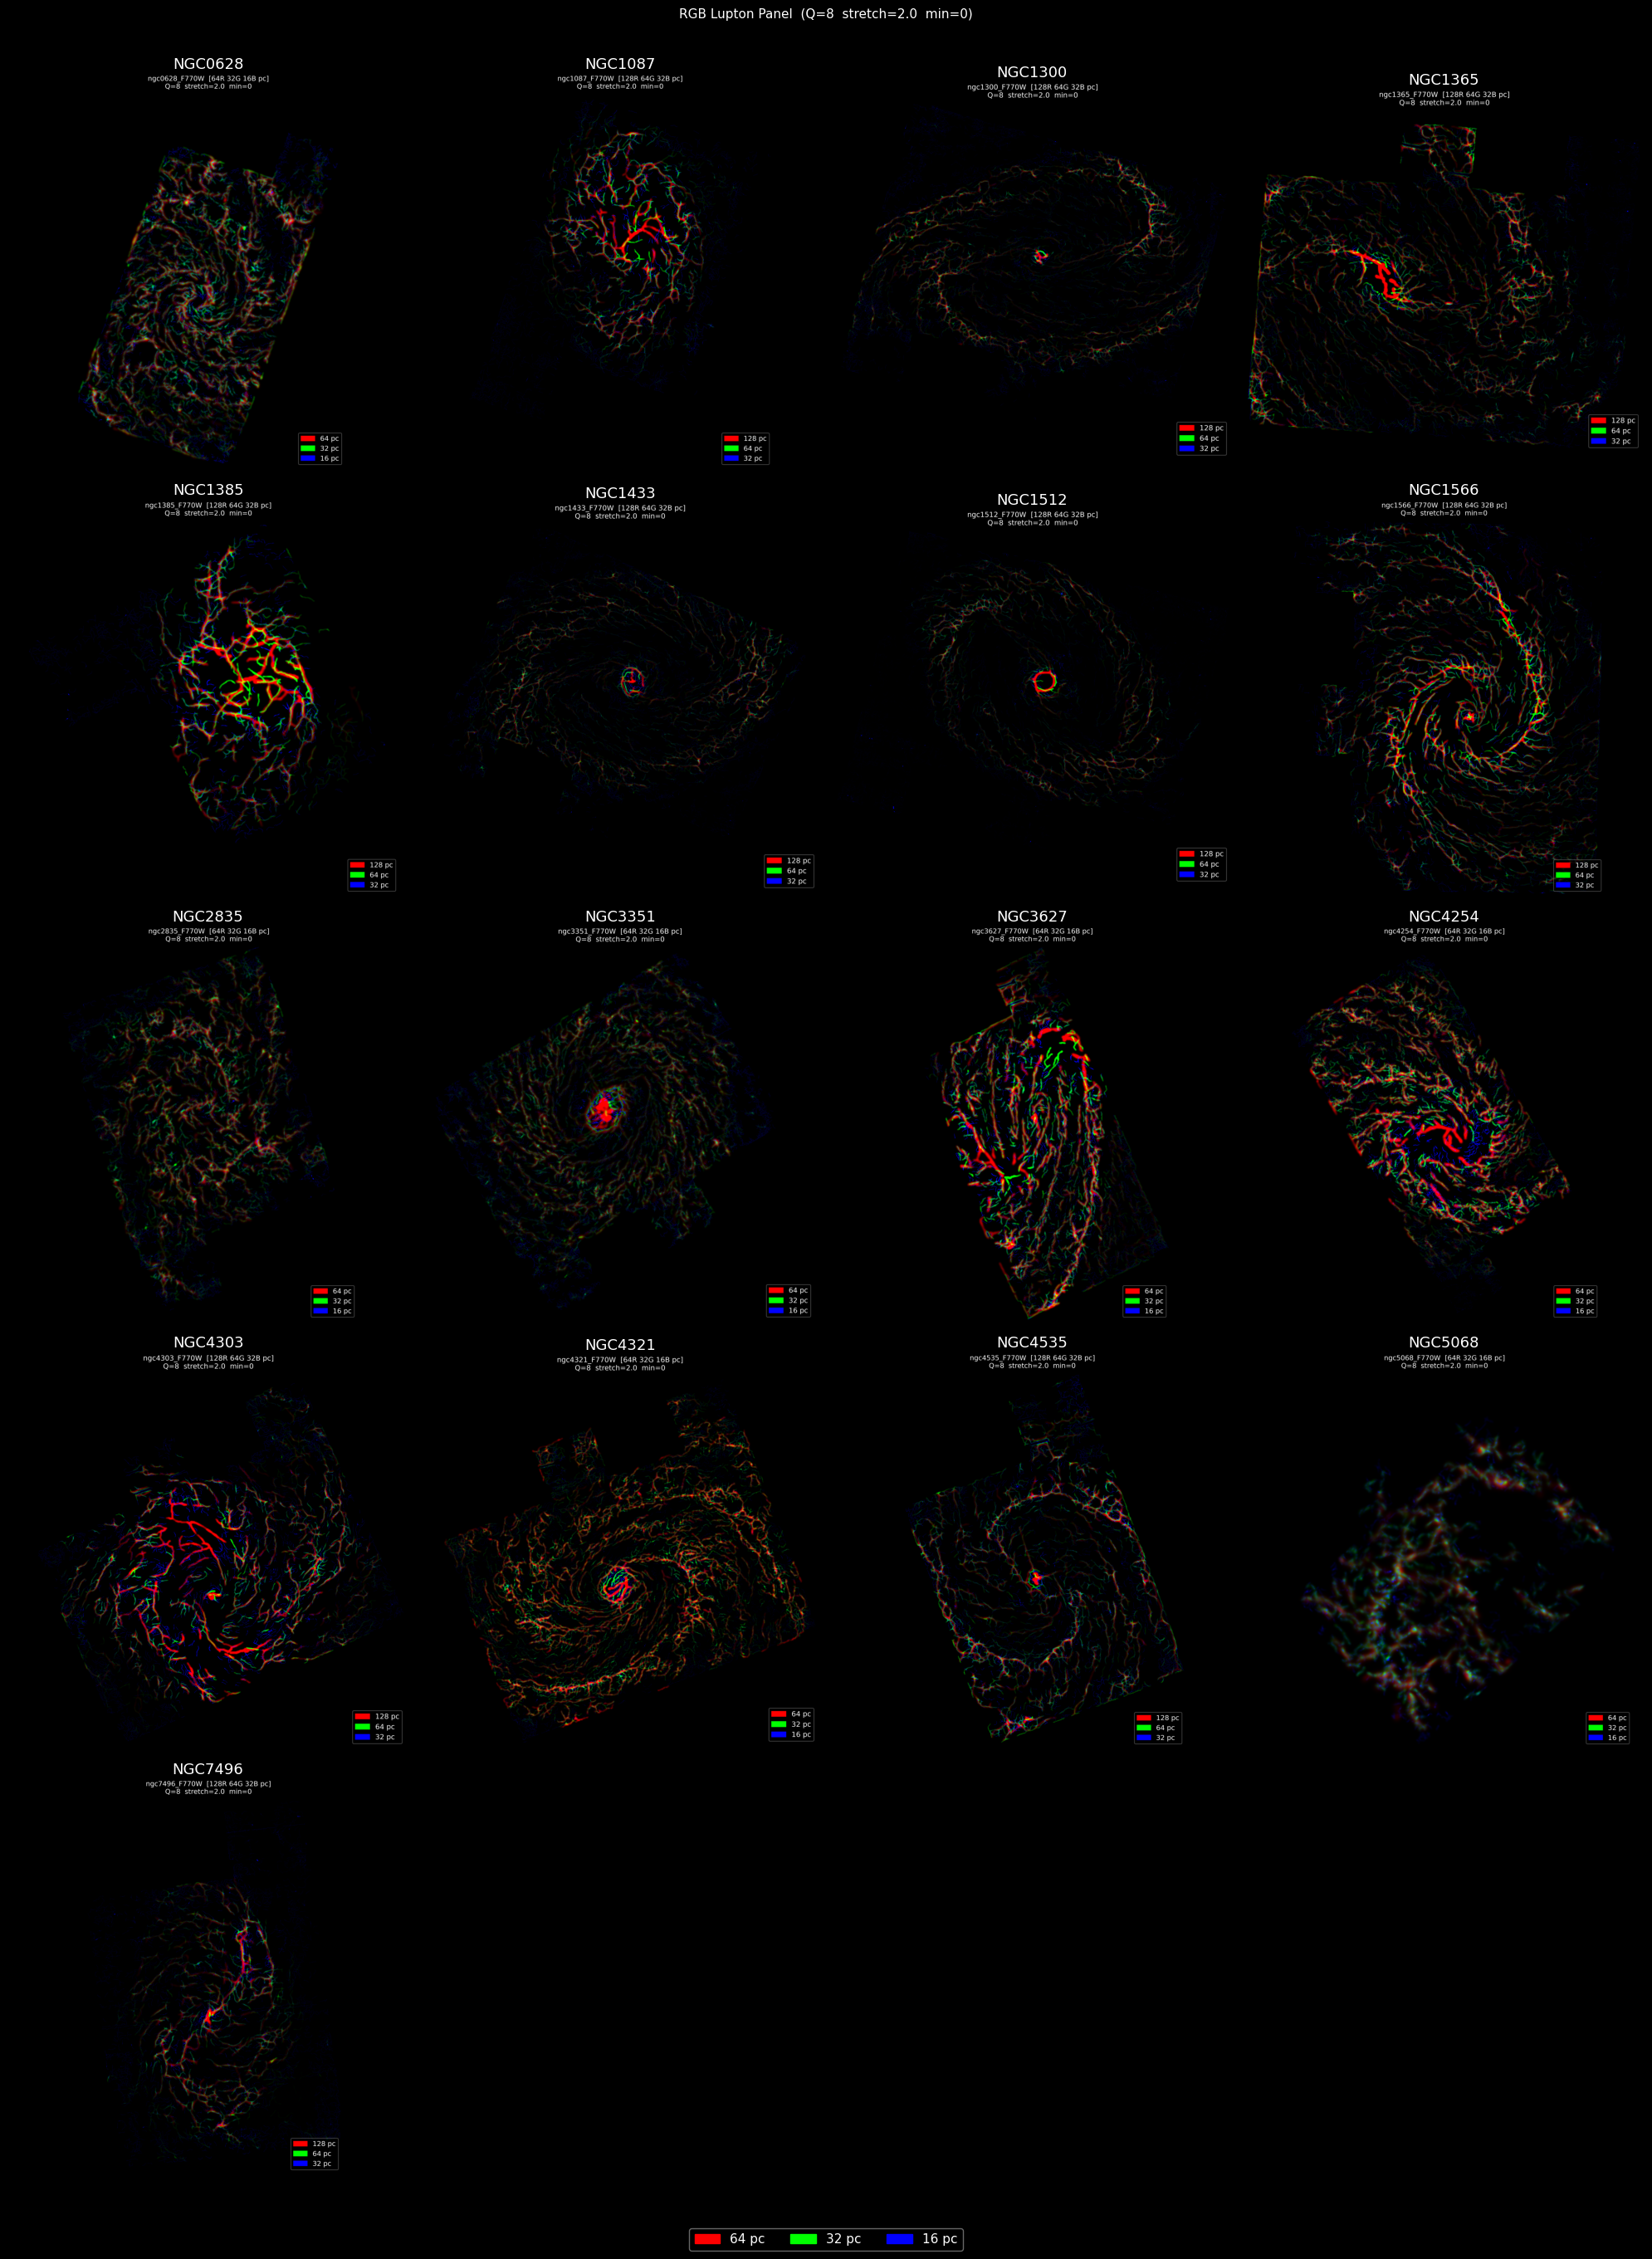

Saved: C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\RGB_Lupton\RGB_Lupton_Panel.png


In [13]:
# =============================================================================
# Cell 4: Multi-Galaxy Lupton RGB Panel
# Assembles per-galaxy PNGs from Cell 3 into a publication-ready grid.
# Set panel_galaxies = None to auto-include all available composites.
# =============================================================================

panel_galaxies = None   # e.g. ["ngc0628_F770W", "ngc4254_F770W"]

if panel_galaxies is None:
    panel_galaxies = sorted([
        f.replace("_RGB_Lupton.png", "")
        for f in os.listdir(OUTPUT_DIR)
        if f.endswith("_RGB_Lupton.png")
    ])

if not panel_galaxies:
    print("No Lupton composites found -- run Cell 3 first.")
else:
    n     = len(panel_galaxies)
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(5 * ncols, 5.5 * nrows),
                              facecolor="black")
    axes_flat = np.array(axes).flatten()

    for ax, gal in zip(axes_flat, panel_galaxies):
        img_path = OUTPUT_DIR / f"{gal}_RGB_Lupton.png"
        title    = gal.replace("_F770W", "").upper()
        ax.set_facecolor("black")
        if img_path.exists():
            ax.imshow(mpimg.imread(img_path))
            ax.set_title(title, fontsize=13, color="white", pad=4)
        else:
            ax.text(0.5, 0.5, f"Run Cell 3 first\n({gal})",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=8, color="red")
            ax.set_title(title, fontsize=13, color="white", pad=4)
        ax.axis("off")

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.legend(handles=legend_handles, loc="lower center",
               ncol=len(legend_handles), fontsize=11,
               facecolor="black", edgecolor="gray", labelcolor="white",
               bbox_to_anchor=(0.5, 0.01))
    _params = f"Q={LUPTON_Q}  stretch={LUPTON_STRETCH}  min={LUPTON_MIN}"
    fig.suptitle(f"RGB Lupton Panel  ({_params})", fontsize=11,
                 color="white", y=0.995)
    plt.tight_layout(rect=[0, 0.04, 1, 0.99])

    out = OUTPUT_DIR / "RGB_Lupton_Panel.png"
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="black")
    plt.show()
    print(f"Saved: {out}")
